# Phase 1 — Flat prior: stationary $q$ across gaps

Sibling of `1c`, which swept the prior concentration $s$ at a fixed gap and horizon and found that the small-$q$ readings produced by strong priors are finite-horizon transients. This notebook isolates the one configuration that **is** stationary: the flat prior $s = 1$. It fixes $\mathrm{Beta}(1,1)$ and the **posterior-gap** criterion (threshold $\delta = \Delta/2$, strictly below the true gap, per the `1b`/`1c` convention), sweeps the gap $\Delta \in \{0.01, 0.1, 0.5\}$, and tracks $\hat q_{\text{gap}}(t)$ continuously over horizons $t$ up to $T = 10000$, with the reporting window $t \in [1000, 10000]$.

The question it answers: **at what value does the stationary $q$ sit, per gap, and how flat is it over the window?** Because the agents are myopic and greedy, learning is incomplete — each agent absorbs onto one arm, so $q$ plateaus at the fraction that commits to $A$ (strictly between $0$ and $1$), not at $1$. The flat prior makes absorption fast, so the plateau is reached well before $t = 1000$ and the window reading is a genuine equilibrium value.

**One simulation per gap.** Rather than re-running the model at each horizon, each gap is simulated once to $T = 10000$ and the posterior-gap at every intermediate $t$ is reconstructed exactly from cumulative pull/success counts (conjugacy makes the time-$t$ posterior a deterministic function of the history prefix). The whole $q(t)$ curve costs one run.

**Restart-and-Run-All-safe.** The sweep is wrapped in `%%time`; `tqdm` shows progress. Flip `SMOKE_TEST = True` for a fast end-to-end check.

## Setup

Local-only (no Colab/Drive). Imports from `model/` in the parent paper folder.

> **Env note.** If the next cell prints a `NumPy 1.x cannot be run in NumPy 2.x` traceback referencing `numexpr`, imports still succeeded (pandas treats it as optional) — silence with `python3 -m pip install -U "numexpr>=2.10"` and restart the kernel.

In [1]:
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

PAPER_ROOT = Path.cwd().resolve().parent
if str(PAPER_ROOT) not in sys.path:
    sys.path.insert(0, str(PAPER_ROOT))
RESULTS_DIR = PAPER_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

from model.bandit import ARM_A, ARM_B, BernoulliBandit
from model.discovery import discovered_by_posterior_gap
from model.simulation import run_simulation

## Parameters

The prior is held **fixed** at flat $\mathrm{Beta}(1,1)$ and the criterion is posterior-gap only; the swept knob is the gap $\Delta$, and the horizon axis comes for free from the trajectory reconstruction. The criterion threshold scales per cell as $\delta = \Delta/2$ (the `1b`/`1c` convention — a fixed absolute $\delta$ would put the $\Delta = 0.01$ cell in the pathological regime $\delta > \Delta$).

In [2]:
SMOKE_TEST = False         # True -> tiny run for kernel-restart smoke tests

# Fixed: flat prior, arms centered at P_MID and pulled apart by each gap:
#   p_A = P_MID + Delta/2,  p_B = P_MID - Delta/2.
PRIOR_S = 1.0              # Beta(1, 1) -- the flat prior; the point of this notebook
P_MID   = 0.5

# Swept knob: the true gap Delta = p_A - p_B.
GAP_GRID = np.array([0.01, 0.1, 0.5])

# Posterior-gap criterion threshold, scaled per cell: delta = Delta/2.
GAP_DELTA_FRACTION = 0.5

# Horizon. One run per gap to T_MAX; q(t) is reconstructed at every t <= T_MAX.
# The reporting window for stationarity is [T_REPORT_MIN, T_MAX].
T_MAX        = 500 if SMOKE_TEST else 10000
T_REPORT_MIN = 100 if SMOKE_TEST else 1000

# In the unaided regime agents are independent, so N_AGENTS is the number of
# i.i.d. samples of D_i per gap (SE = sqrt(q(1-q)/N_AGENTS)).
N_AGENTS = 100 if SMOKE_TEST else 500

# Checkpoints for the stationarity table.
CHECKPOINTS = np.arange(T_REPORT_MIN, T_MAX + 1, T_REPORT_MIN)

MASTER_SEED = 20260610
STAMP = datetime.now().strftime('%Y%m%d_%H%M%S')

print(f'SMOKE_TEST={SMOKE_TEST}  prior=Beta({PRIOR_S:g},{PRIOR_S:g})  '
      f'gaps={GAP_GRID.tolist()}  delta=Delta*{GAP_DELTA_FRACTION}  '
      f'T_max={T_MAX}  n_agents/gap={N_AGENTS}  seed={MASTER_SEED}')

SMOKE_TEST=False  prior=Beta(1,1)  gaps=[0.01, 0.1, 0.5]  delta=Delta*0.5  T_max=10000  n_agents/gap=500  seed=20260610


## Posterior-gap trajectory (vectorized, exact)

By conjugacy, the time-$t$ posterior on arm $a$ is $\mathrm{Beta}(s + \text{successes}_a(t),\; s + \text{failures}_a(t))$, a deterministic function of the history prefix. So cumulative sums over the recorded history give the posterior mean of every agent at every step, and one simulation yields the full curve

$$\hat q_{\text{gap}}(t) = \frac{1}{n}\sum_{i=1}^{n} \mathbf{1}\{\mathbb{E}[p_A \mid h_i^t] - \mathbb{E}[p_B \mid h_i^t] \ge \delta\}.$$

Reading the formula: $n$ is the total number of agents in the community (`N_AGENTS`), and $i$ indexes the agents, $i = 1, \ldots, n$. For agent $i$, $h_i^t$ is its history through step $t$ (the arms it pulled and the outcomes it saw), so $\mathbb{E}[p_A \mid h_i^t]$ and $\mathbb{E}[p_B \mid h_i^t]$ are that agent's posterior-mean beliefs about each arm at time $t$. The indicator $\mathbf{1}\{\cdot\}$ is $1$ when agent $i$'s belief gap clears the discovery threshold $\delta$ (i.e. agent $i$ counts as having discovered the better arm at time $t$) and $0$ otherwise. Averaging the indicator over all $n$ agents gives the fraction of the community that has discovered $A$ by time $t$ — the Monte-Carlo estimate $\hat q_{\text{gap}}(t)$ of the individual discovery probability $q$ at horizon $t$. In the unaided regime the agents are i.i.d., so this fraction is just $n$ independent samples of the discovery event $D_i$.

The cell below defines the reconstruction and asserts it agrees with `discovered_by_posterior_gap` (which reads the simulator's own final posterior) at $t = T$ on a small sample, so the notebook cannot drift from the module's definition.

In [3]:
def posterior_gap_trajectory(histories, s):
    """Exact E[p_A | h^t] - E[p_B | h^t] for every agent at every t.

    histories : (n_agents, T, 2) int array of [arm_pulled, outcome] rows.
    Returns (n_agents, T) float array; column t uses the first t+1 steps.
    """
    arms, outs = histories[:, :, 0], histories[:, :, 1]
    means = []
    for arm in (ARM_A, ARM_B):
        pulled = arms == arm
        succ = np.cumsum(pulled & (outs == 1), axis=1)
        pulls = np.cumsum(pulled, axis=1)
        means.append((s + succ) / (2 * s + pulls))
    return means[0] - means[1]


# Consistency check against the module criterion at t = T.
_chk = run_simulation(BernoulliBandit(p_a=0.6, p_b=0.4),
                      n_agents=50, n_steps=60, seed=0)
_chk_delta = (0.6 - 0.4) * GAP_DELTA_FRACTION
_traj = posterior_gap_trajectory(_chk.histories, s=PRIOR_S)
_ref = np.array([
    discovered_by_posterior_gap(_chk.histories[i], _chk.final_alpha_beta[i], delta=_chk_delta)
    for i in range(_chk.n_agents)
])
assert np.array_equal(_traj[:, -1] >= _chk_delta, _ref), 'trajectory drifted from model/discovery.py'
print('trajectory reconstruction matches discovered_by_posterior_gap at t=T')

trajectory reconstruction matches discovered_by_posterior_gap at t=T


## Run the gap sweep

One community of `N_AGENTS` independent agents per gap, simulated once to `T_MAX` from the shared flat prior; $\hat q_{\text{gap}}(t)$ and its binomial SE are then read off the reconstructed trajectories at every $t$. Per-gap seeds are spawned from `MASTER_SEED` so the sweep is reproducible.

In [4]:
%%time
ss = np.random.SeedSequence(MASTER_SEED)
gap_seeds = [int(x.generate_state(1)[0]) for x in ss.spawn(len(GAP_GRID))]

prior = np.array([[PRIOR_S, PRIOR_S], [PRIOR_S, PRIOR_S]])
q_curves = {}                       # gap -> (T_MAX,) array of q_hat(t)
final_gaps = {}                     # gap -> (N_AGENTS,) final posterior gaps, for the histogram cell
for gap, seed in zip(tqdm(GAP_GRID, desc='gap sweep'), gap_seeds):
    p_a, p_b = P_MID + gap / 2, P_MID - gap / 2
    res = run_simulation(bandit=BernoulliBandit(p_a=p_a, p_b=p_b),
                         n_agents=N_AGENTS, n_steps=T_MAX,
                         prior_alpha_beta=prior, seed=seed)
    traj = posterior_gap_trajectory(res.histories, s=PRIOR_S)
    q_curves[float(gap)] = (traj >= gap * GAP_DELTA_FRACTION).mean(axis=0)
    final_gaps[float(gap)] = traj[:, -1]

curves = pd.DataFrame(q_curves, index=np.arange(1, T_MAX + 1)).rename_axis('t')
curves.loc[CHECKPOINTS]

gap sweep:   0%|          | 0/3 [00:00<?, ?it/s]

CPU times: user 4min 2s, sys: 3.95 s, total: 4min 6s
Wall time: 4min 13s


,0.01,0.10,0.50
t,,,
1000,0.492,0.636,0.824
2000,0.492,0.628,0.810
3000,0.488,0.622,0.804
4000,0.488,0.616,0.808
5000,0.490,0.614,0.826
6000,0.492,0.618,0.834
7000,0.490,0.622,0.826
8000,0.490,0.620,0.830
9000,0.490,0.614,0.814


## $\hat q_{\text{gap}}(t)$ trajectories

The full curve from $t = 1$, with the reporting window $[10^3, 10^4]$ shaded. Stationarity is flatness inside the window. Bands are $\pm 1$ binomial SE.

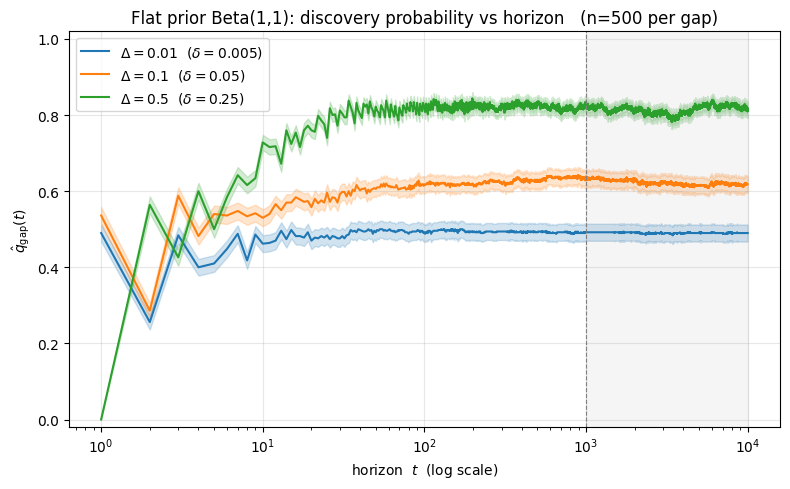

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
t = curves.index.values
for gap in GAP_GRID:
    q = curves[float(gap)].values
    se = np.sqrt(q * (1 - q) / N_AGENTS)
    line, = ax.plot(t, q, label=rf'$\Delta={gap:g}$  ($\delta={gap * GAP_DELTA_FRACTION:g}$)')
    ax.fill_between(t, q - se, q + se, alpha=0.2, color=line.get_color())
ax.axvspan(T_REPORT_MIN, T_MAX, color='grey', alpha=0.08)
ax.axvline(T_REPORT_MIN, color='grey', lw=0.8, ls='--')
ax.set_xscale('log')
ax.set_xlabel(r'horizon  $t$  (log scale)')
ax.set_ylabel(r'$\hat q_{\mathrm{gap}}(t)$')
ax.set_ylim(-0.02, 1.02)
ax.set_title(f'Flat prior Beta(1,1): discovery probability vs horizon   (n={N_AGENTS} per gap)')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
traj_fig_path = RESULTS_DIR / f'phase1_flat_prior_q_traj_{STAMP}.png'
fig.savefig(traj_fig_path, dpi=150)
plt.show()

## Stationarity over the reporting window

$\hat q_{\text{gap}}$ at each checkpoint $t \in \{1000, 2000, \ldots, 10000\}$, plus the drift (max $-$ min) across the window per gap. A drift within $\sim 2$ binomial SE is flat to Monte-Carlo resolution.

In [6]:
table = curves.loc[CHECKPOINTS].T.rename_axis('gap')
table.columns = [f't={c}' for c in CHECKPOINTS]

q_ref = curves.loc[CHECKPOINTS].iloc[-1]
drift = curves.loc[CHECKPOINTS].max() - curves.loc[CHECKPOINTS].min()
two_se = 2 * np.sqrt(q_ref * (1 - q_ref) / N_AGENTS)
table['drift'] = drift.values
table['2*SE'] = two_se.values
table['stationary'] = np.where(drift.values <= two_se.values, 'yes', 'NO')

for gap in GAP_GRID:
    row = table.loc[float(gap)]
    print(f'gap={gap:g}: q in [{drift.name if False else ""}'
          f'{curves.loc[CHECKPOINTS, float(gap)].min():.3f}, '
          f'{curves.loc[CHECKPOINTS, float(gap)].max():.3f}] over the window; '
          f'drift={row["drift"]:.3f} vs 2*SE={row["2*SE"]:.3f} -> {row["stationary"]}')
table.round(3)

gap=0.01: q in [0.488, 0.492] over the window; drift=0.004 vs 2*SE=0.045 -> yes
gap=0.1: q in [0.614, 0.636] over the window; drift=0.022 vs 2*SE=0.043 -> yes
gap=0.5: q in [0.804, 0.834] over the window; drift=0.030 vs 2*SE=0.035 -> yes


,t=1000,t=2000,t=3000,t=4000,t=5000,t=6000,t=7000,t=8000,t=9000,t=10000,drift,2*SE,stationary
gap,,,,,,,,,,,,,
0.01,0.492,0.492,0.488,0.488,0.490,0.492,0.490,0.49,0.490,0.490,0.004,0.045,yes
0.10,0.636,0.628,0.622,0.616,0.614,0.618,0.622,0.62,0.614,0.618,0.022,0.043,yes
0.50,0.824,0.810,0.804,0.808,0.826,0.834,0.826,0.83,0.814,0.814,0.030,0.035,yes


## Where the agents end up: final posterior-gap distribution

The histogram of $\mathbb{E}[p_A \mid h^T] - \mathbb{E}[p_B \mid h^T]$ across agents at $T = T_{\max}$, per gap, with the criterion threshold $\delta$ (dashed) and the true gap $\Delta$ (dotted) marked. The final gaps were stored by the sweep cell (`final_gaps`, the last column of each reconstructed trajectory), so this cell is plot-only — no re-simulation. This is the absorption picture behind the plateau: each agent has committed to one arm, so the distribution is bimodal — a mass near $+\Delta$ (settled on $A$, counted by the criterion) and a mass below $\delta$ (settled on $B$, frozen at a wrong belief). The stationary $q$ is the weight of the right mode.

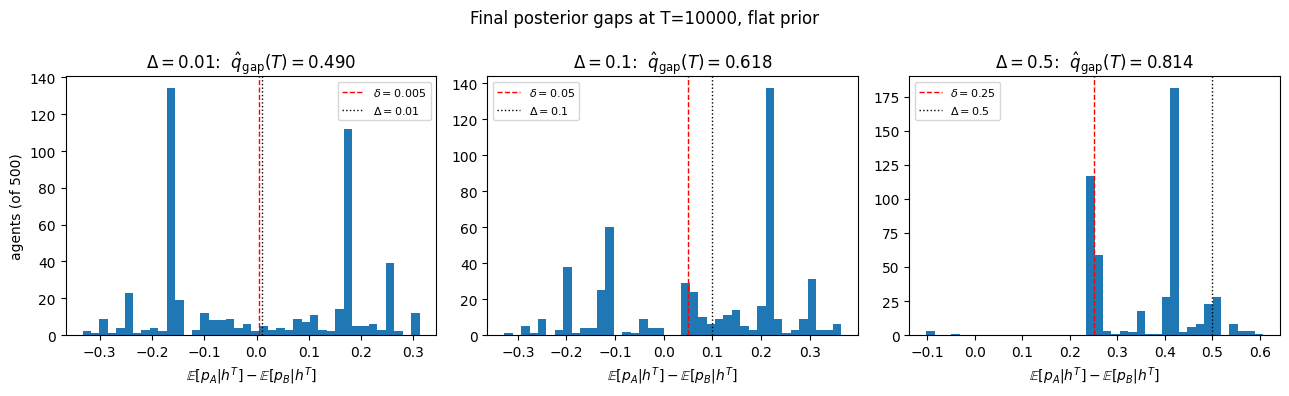

In [7]:
fig, axes = plt.subplots(1, len(GAP_GRID), figsize=(13, 4))
for ax, gap in zip(axes, GAP_GRID):
    final_gap = final_gaps[float(gap)]
    ax.hist(final_gap, bins=40)
    ax.axvline(gap * GAP_DELTA_FRACTION, color='red', ls='--', lw=1,
               label=rf'$\delta={gap * GAP_DELTA_FRACTION:g}$')
    ax.axvline(gap, color='black', ls=':', lw=1, label=rf'$\Delta={gap:g}$')
    ax.set_title(rf'$\Delta={gap:g}$:  $\hat q_{{\mathrm{{gap}}}}(T)={q_curves[float(gap)][-1]:.3f}$')
    ax.set_xlabel(r'$\mathbb{E}[p_A|h^T]-\mathbb{E}[p_B|h^T]$')
    ax.legend(fontsize=8)
axes[0].set_ylabel(f'agents (of {N_AGENTS})')
fig.suptitle(f'Final posterior gaps at T={T_MAX}, flat prior')
fig.tight_layout()
hist_fig_path = RESULTS_DIR / f'phase1_flat_prior_gap_hist_{STAMP}.png'
fig.savefig(hist_fig_path, dpi=150)
plt.show()

## Save

Persist $\hat q_{\text{gap}}(t)$ at the checkpoints as a timestamped CSV under [`results/`](../results/) (long format: one row per gap $\times$ checkpoint), alongside the two figures already written by the plot cells.

In [8]:
rows = []
for gap in GAP_GRID:
    for t in CHECKPOINTS:
        q = float(curves.loc[t, float(gap)])
        rows.append({'gap': float(gap), 'gap_delta': float(gap) * GAP_DELTA_FRACTION,
                     'prior_s': PRIOR_S, 't': int(t), 'criterion': 'posterior_gap',
                     'q_hat': q, 'se': float(np.sqrt(q * (1 - q) / N_AGENTS))})
flat = pd.DataFrame(rows)
csv_path = RESULTS_DIR / f'phase1_flat_prior_q_{STAMP}.csv'
flat.to_csv(csv_path, index=False)
print(f'checkpoint table -> {csv_path.relative_to(PAPER_ROOT)}')
print(f'trajectory fig   -> {traj_fig_path.relative_to(PAPER_ROOT)}')
print(f'histogram fig    -> {hist_fig_path.relative_to(PAPER_ROOT)}')

checkpoint table -> results/phase1_flat_prior_q_20260610_163725.csv
trajectory fig   -> results/phase1_flat_prior_q_traj_20260610_163725.png
histogram fig    -> results/phase1_flat_prior_gap_hist_20260610_163725.png


## What this shows

- **The flat prior is stationary at every gap.** Over the reporting window $t \in [1000, 10000]$ the drift in $\hat q_{\text{gap}}$ is within $2$ binomial SE for all three gaps ($0.004$, $0.022$, $0.030$ vs $2\,\mathrm{SE} \approx 0.035$–$0.045$). The $t = 1000$ reading already equals the $t = 10000$ reading: under $\mathrm{Beta}(1,1)$, the §2 operating horizon $T = 1000$ is comfortably inside equilibrium. This is the converse of `1c`'s finding for strong priors, whose $q$ readings at $T = 1000$ are transients still climbing toward the absorption ceiling.
- **The stationary $q$ rises with the gap but never approaches $1$:**

  | $\Delta$ | $\delta = \Delta/2$ | stationary $\hat q_{\text{gap}}$ |
  |---|---|---|
  | $0.01$ | $0.005$ | $\approx 0.49$ |
  | $0.10$ | $0.05$ | $\approx 0.62$ |
  | $0.50$ | $0.25$ | $\approx 0.82$ |

  Even at $\Delta = 0.5$ — arms at $p_A = 0.75$ vs $p_B = 0.25$, as easy as the problem plausibly gets — roughly one agent in five fails to discover. Learning is incomplete: greedy play absorbs some agents onto $B$ early, the abandoned arm's posterior freezes, and no amount of further data revisits it.
- **At a small gap the stationary $q$ is a coin flip.** $\Delta = 0.01$ gives $q \approx 0.49$, matching §2's absorption argument: once beliefs converge, the criterion just counts "settled on $A$", and at a near-symmetric problem that event is close to fair. The threshold $\delta$ has no leverage here — anyone settled on $A$ clears any $\delta \lesssim \Delta$.
- **The histogram makes the mechanism visible.** The final posterior-gap distribution is bimodal at every gap: a right mode near $+\Delta$ (settled on $A$, counted) and a left mass below $\delta$ (settled on $B$, with frozen wrong beliefs). The stationary $q$ is exactly the weight of the right mode.
- **Implication for the paper.** If the baseline calibration adopts the flat prior, the unaided individual discovery probability is an honest *equilibrium* quantity, $q \approx 0.5$–$0.8$ depending on the gap — not a finite-horizon artefact. The price (per `1c` and the §2 stationarity paragraph) is giving up the rare-discovery regime: no stationary $q$ near $0.05$ exists in this model at any gap.
- **Retargeting.** Change `GAP_GRID` or `GAP_DELTA_FRACTION` and re-run; one simulation per gap yields the full $q(t)$ curve, so adding gaps is cheap (~80 s each at the laptop tier).